In [24]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from scipy.stats import kurtosis, skew
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

In [25]:
# === USER CONFIGURATION ===
BASE_PATH = r"D:\MSC TUNI\AA Thesis\IMS"

TEST_CONFIGS = {
    '1st_test': {
        'path': os.path.join(BASE_PATH, '1st_test'),
        'n_channels': 8,
        'bearings': {
            'Bearing1': [0, 1],  # column indices (0-based)
            'Bearing2': [2, 3],
            'Bearing3': [4, 5],
            'Bearing4': [6, 7],
        },
        'failed': 'Bearing3 (inner race), Bearing4 (roller element)',
        'fs': 20000,  # sampling rate Hz
        'n_samples': 20480,
    },
    '2nd_test': {
        'path': os.path.join(BASE_PATH, '2nd_test'),
        'n_channels': 4,
        'bearings': {
            'Bearing1': [0],
            'Bearing2': [1],
            'Bearing3': [2],
            'Bearing4': [3],
        },
        'failed': 'Bearing1 (outer race)',
        'fs': 20000,
        'n_samples': 20480,
    },
    '3rd_test': {
        'path': os.path.join(BASE_PATH, '3rd_test'),
        'n_channels': 4,
        'bearings': {
            'Bearing1': [0],
            'Bearing2': [1],
            'Bearing3': [2],
            'Bearing4': [3],
        },
        'failed': 'Bearing3 (outer race)',
        'fs': 20000,
        'n_samples': 20480,
    },
}

print("Configuration loaded.")
for run, cfg in TEST_CONFIGS.items():
    print(f"  {run}: {cfg['n_channels']} channels | Failed: {cfg['failed']}")

Configuration loaded.
  1st_test: 8 channels | Failed: Bearing3 (inner race), Bearing4 (roller element)
  2nd_test: 4 channels | Failed: Bearing1 (outer race)
  3rd_test: 4 channels | Failed: Bearing3 (outer race)


In [26]:
def parse_timestamp(filename):
    """Parse IMS filename into datetime. Format: YYYY.MM.DD.HH.MM.SS"""
    basename = os.path.basename(filename)
    try:
        return datetime.strptime(basename, "%Y.%m.%d.%H.%M.%S")
    except ValueError:
        return None

def get_file_list(run_key):
    """Return sorted list of (datetime, filepath) tuples for a test run."""
    cfg = TEST_CONFIGS[run_key]
    files = sorted(glob.glob(os.path.join(cfg['path'], '*')))
    result = []
    for f in files:
        ts = parse_timestamp(f)
        if ts is not None:
            result.append((ts, f))
    return result

# Preview file discovery
for run in TEST_CONFIGS:
    files = get_file_list(run)
    if files:
        print(f"{run}: {len(files)} files | {files[0][0]} → {files[-1][0]}")
    else:
        print(f"{run}: No files found — check path!")

1st_test: 2156 files | 2003-10-22 12:06:24 → 2003-11-25 23:39:56
2nd_test: 984 files | 2004-02-12 10:32:39 → 2004-02-19 06:22:39
3rd_test: 6324 files | 2004-03-04 09:27:46 → 2004-04-18 02:42:55


In [27]:
def load_file(filepath, n_channels):
    """Load a single IMS snapshot file into a numpy array (n_samples x n_channels)."""
    data = pd.read_csv(filepath, sep='\t', header=None).values
    assert data.shape == (20480, n_channels), \
        f"Unexpected shape {data.shape} in {filepath}"
    return data  # shape: (20480, n_channels)

# Quick test
run = '1st_test'
files = get_file_list(run)
sample_data = load_file(files[0][1], TEST_CONFIGS[run]['n_channels'])
print(f"Sample file shape: {sample_data.shape}")
print(f"Value range: [{sample_data.min():.4f}, {sample_data.max():.4f}]")

Sample file shape: (20480, 8)
Value range: [-0.7840, 0.7010]


In [28]:
def extract_features(data_1d):
    """Extract time-domain statistical features from a 1D vibration signal."""
    return {
        'rms':      np.sqrt(np.mean(data_1d**2)),
        'peak':     np.max(np.abs(data_1d)),
        'kurtosis': kurtosis(data_1d),
        'skewness': skew(data_1d),
        'crest':    np.max(np.abs(data_1d)) / (np.sqrt(np.mean(data_1d**2)) + 1e-12),
        'std':      np.std(data_1d),
        'mean_abs': np.mean(np.abs(data_1d)),
    }

# Test on one channel
feat = extract_features(sample_data[:, 0])
print("Features for channel 0:", {k: round(v, 4) for k, v in feat.items()})

Features for channel 0: {'rms': 0.1246, 'peak': 0.72, 'kurtosis': 1.0692, 'skewness': -0.03, 'crest': 5.7779, 'std': 0.0811, 'mean_abs': 0.1041}


In [29]:
def build_feature_df(run_key):
    """Compute features for every file and every bearing channel in a test run."""
    cfg = TEST_CONFIGS[run_key]
    files = get_file_list(run_key)
    records = []

    for ts, fpath in files:
        try:
            data = load_file(fpath, cfg['n_channels'])
        except Exception as e:
            print(f"Skipping {fpath}: {e}")
            continue

        for bearing, col_idxs in cfg['bearings'].items():
            # Average features across channels for multi-channel bearings
            feat_list = [extract_features(data[:, c]) for c in col_idxs]
            avg_feat = {k: np.mean([f[k] for f in feat_list]) for k in feat_list[0]}
            row = {'timestamp': ts, 'run': run_key, 'bearing': bearing}
            row.update(avg_feat)
            records.append(row)

    df = pd.DataFrame(records)
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

# Build for all runs (this may take a few minutes for 1st_test with 2156 files)
dfs = {}
for run in TEST_CONFIGS:
    print(f"Processing {run}...")
    dfs[run] = build_feature_df(run)
    print(f"  → {len(dfs[run])} rows")

Processing 1st_test...
  → 8624 rows
Processing 2nd_test...
  → 3936 rows
Processing 3rd_test...
  → 25296 rows


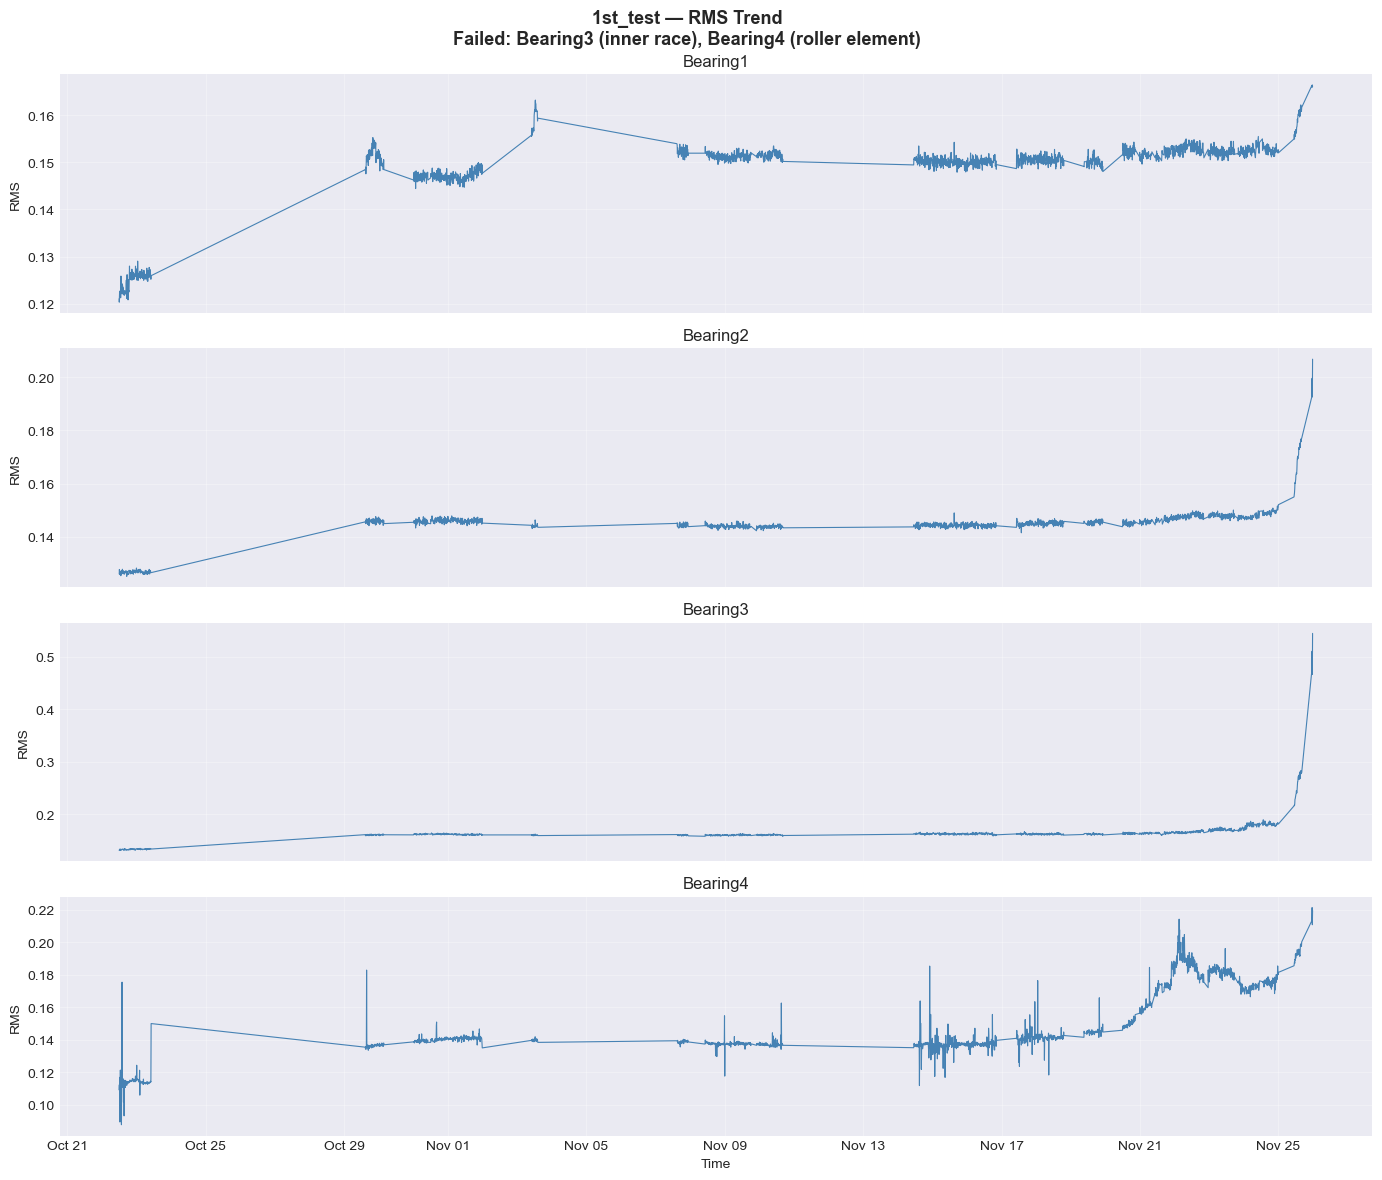

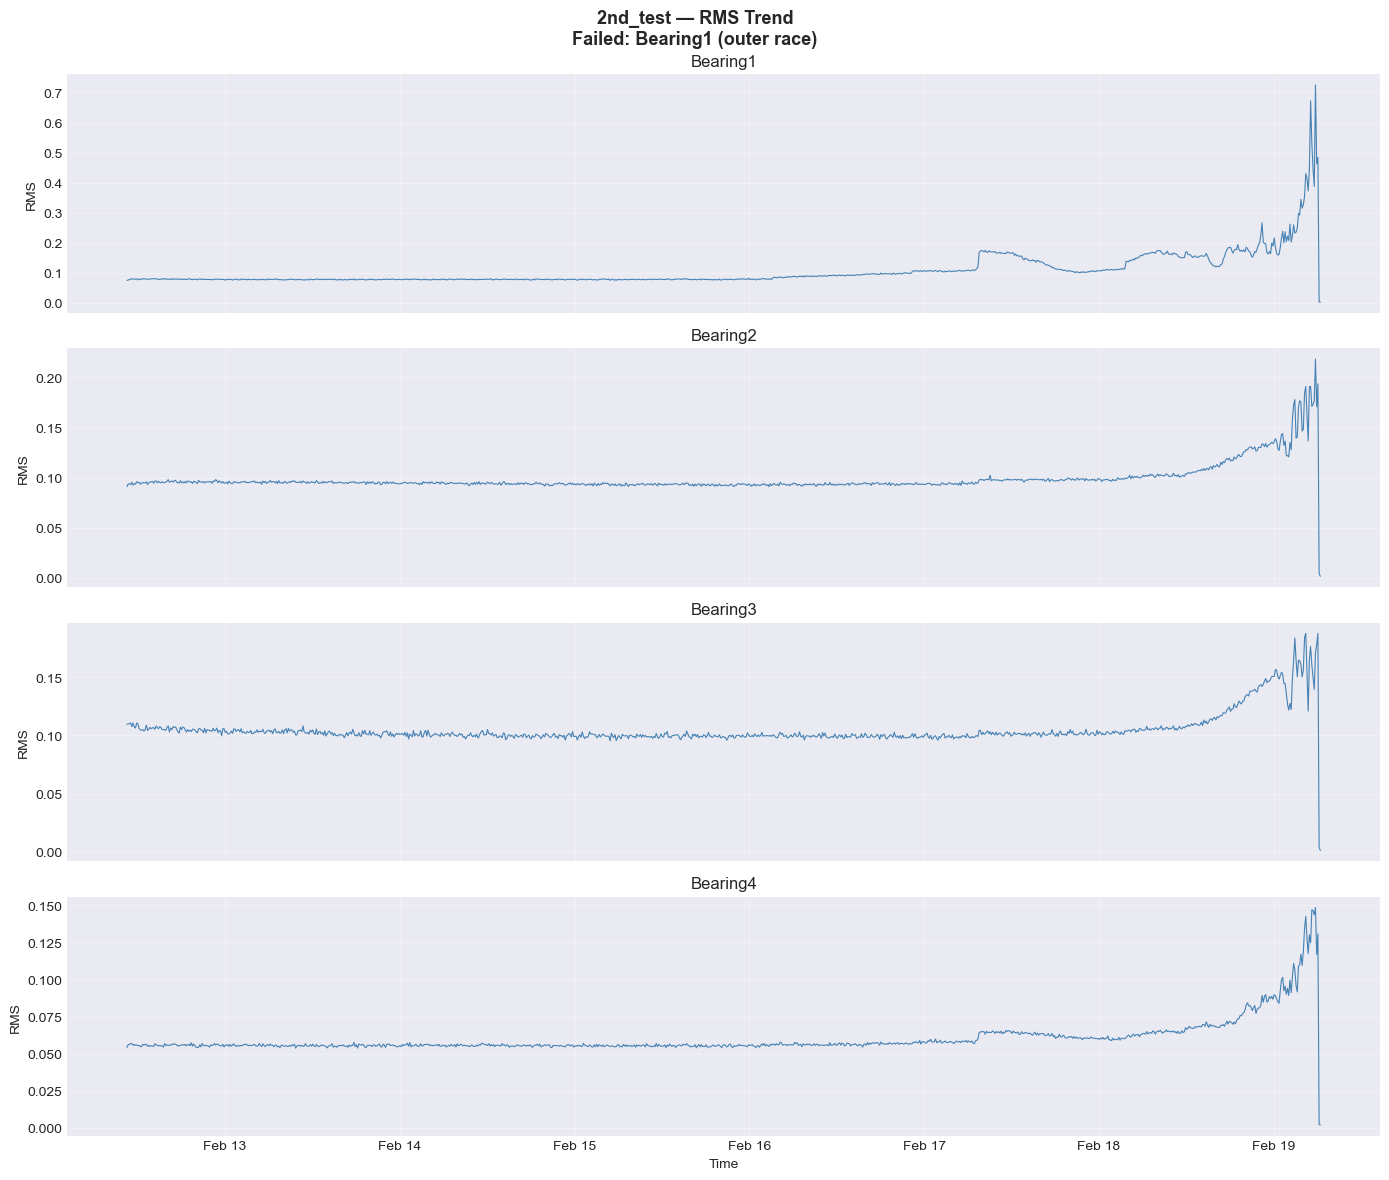

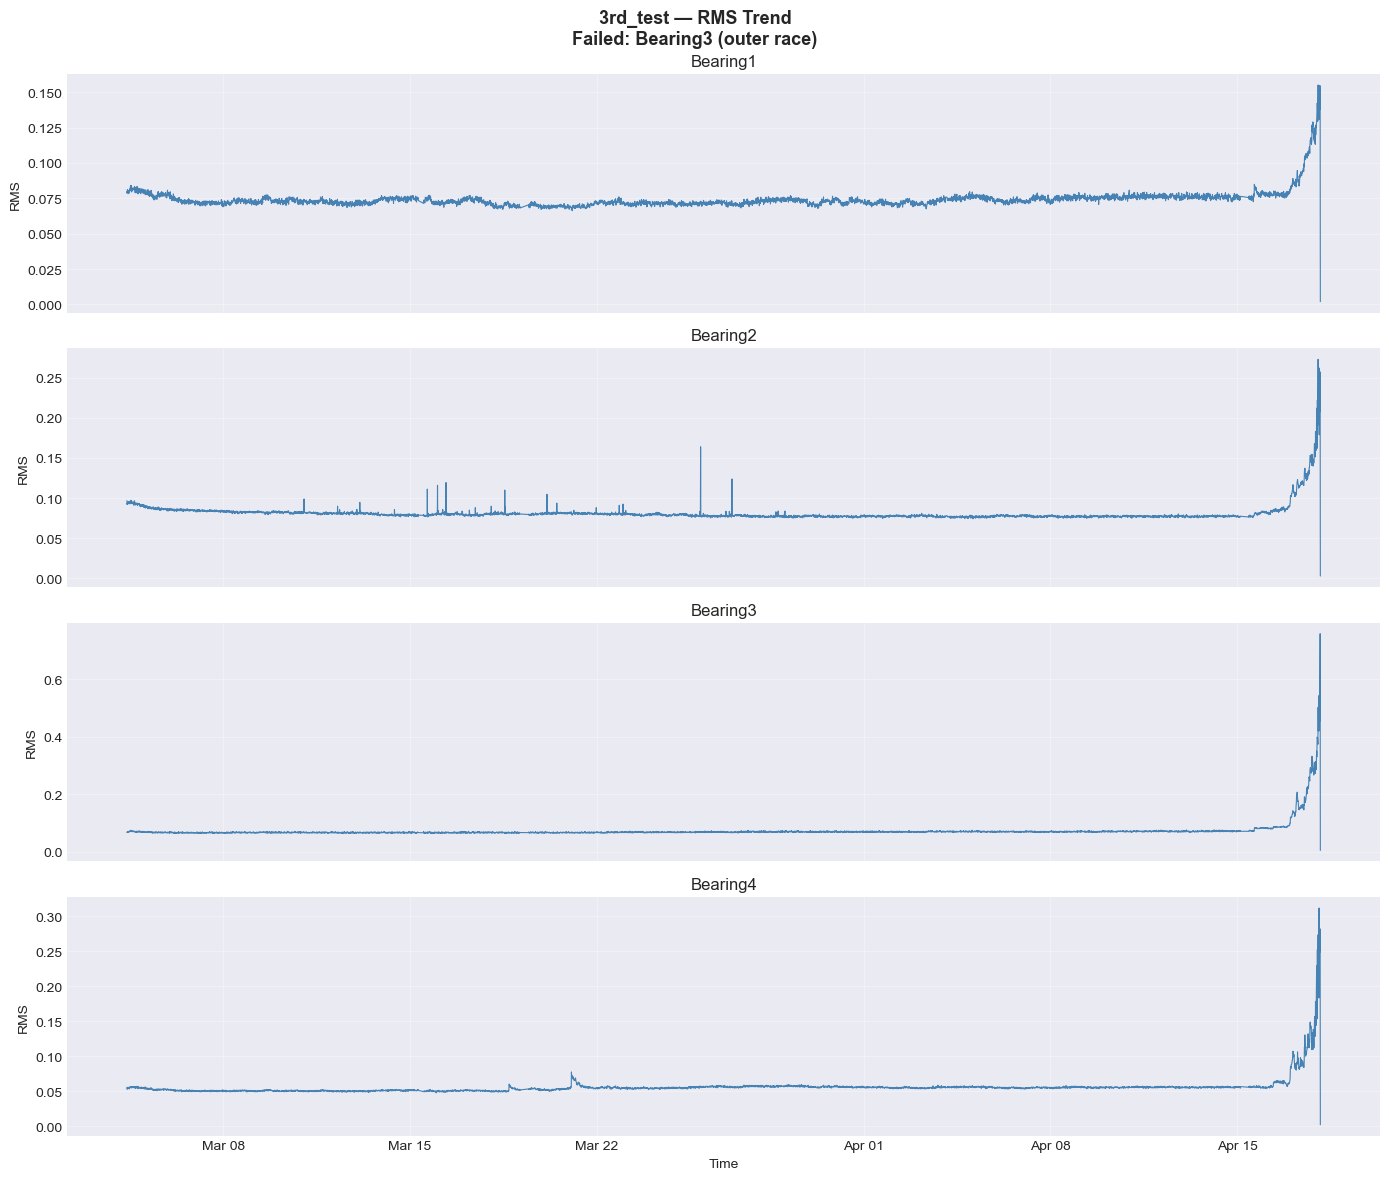

In [30]:
def plot_rms_trend(run_key, feature='rms'):
    df = dfs[run_key]
    bearings = df['bearing'].unique()
    cfg = TEST_CONFIGS[run_key]

    fig, axes = plt.subplots(len(bearings), 1, figsize=(14, 3 * len(bearings)), sharex=True)
    if len(bearings) == 1:
        axes = [axes]

    for ax, bearing in zip(axes, sorted(bearings)):
        sub = df[df['bearing'] == bearing]
        ax.plot(sub['timestamp'], sub[feature], linewidth=0.8, color='steelblue')
        ax.set_ylabel(feature.upper())
        ax.set_title(f'{bearing}')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time')
    fig.suptitle(f'{run_key} — {feature.upper()} Trend\nFailed: {cfg["failed"]}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for run in TEST_CONFIGS:
    plot_rms_trend(run)

In [ ]:
for run in TEST_CONFIGS:
    plot_rms_trend(run, feature='kurtosis')

In [ ]:
def plot_waveform_comparison(run_key, bearing='Bearing1'):
    cfg = TEST_CONFIGS[run_key]
    files = get_file_list(run_key)
    col_idx = cfg['bearings'][bearing][0]  # first channel of bearing

    first_ts, first_file = files[0]
    last_ts, last_file = files[-1]

    d_first = load_file(first_file, cfg['n_channels'])[:, col_idx]
    d_last  = load_file(last_file,  cfg['n_channels'])[:, col_idx]

    t = np.arange(cfg['n_samples']) / cfg['fs'] * 1000  # ms

    fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=False)
    axes[0].plot(t, d_first, linewidth=0.5, color='royalblue')
    axes[0].set_title(f'First snapshot: {first_ts}')
    axes[1].plot(t, d_last,  linewidth=0.5, color='crimson')
    axes[1].set_title(f'Last snapshot: {last_ts}')

    for ax in axes:
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Acceleration (g)')
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'{run_key} — {bearing} Waveform: Start vs End', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_waveform_comparison('1st_test', bearing='Bearing3')  # failed bearing
plot_waveform_comparison('2nd_test', bearing='Bearing1')
plot_waveform_comparison('3rd_test', bearing='Bearing3')

In [ ]:
def plot_fft_comparison(run_key, bearing='Bearing1'):
    cfg = TEST_CONFIGS[run_key]
    files = get_file_list(run_key)
    col_idx = cfg['bearings'][bearing][0]

    first_ts, first_file = files[0]
    last_ts,  last_file  = files[-1]

    d_first = load_file(first_file, cfg['n_channels'])[:, col_idx]
    d_last  = load_file(last_file,  cfg['n_channels'])[:, col_idx]

    def compute_fft(sig, fs):
        n = len(sig)
        freqs = np.fft.rfftfreq(n, d=1/fs)
        mag   = np.abs(np.fft.rfft(sig)) * 2 / n
        return freqs, mag

    f1, m1 = compute_fft(d_first, cfg['fs'])
    f2, m2 = compute_fft(d_last,  cfg['fs'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    axes[0].plot(f1, m1, linewidth=0.5, color='royalblue')
    axes[0].set_title(f'First snapshot: {first_ts}')
    axes[1].plot(f2, m2, linewidth=0.5, color='crimson')
    axes[1].set_title(f'Last snapshot: {last_ts}')

    for ax in axes:
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Amplitude')
        ax.set_xlim(0, cfg['fs'] / 2)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'{run_key} — {bearing} FFT Spectrum: Start vs End', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_fft_comparison('1st_test', bearing='Bearing3')
plot_fft_comparison('2nd_test', bearing='Bearing1')
plot_fft_comparison('3rd_test', bearing='Bearing3')

In [ ]:
for run in TEST_CONFIGS:
    df = dfs[run]
    print(f"\n{'='*50}")
    print(f"  {run}  |  Failed: {TEST_CONFIGS[run]['failed']}")
    print(f"{'='*50}")
    print(df.groupby('bearing')[['rms','kurtosis','crest','peak']].describe().round(4))

In [ ]:
for run in TEST_CONFIGS:
    out_path = os.path.join(BASE_PATH, f'features_{run}.csv')
    dfs[run].to_csv(out_path, index=False)
    print(f"Saved: {out_path}")